In [59]:
import numpy as np
import pandas as pd
import seaborn as sns
from sklearn.metrics import roc_curve, roc_auc_score
import matplotlib.pyplot as plt
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LinearRegression
from sklearn.preprocessing import LabelEncoder, StandardScaler
from sklearn.linear_model import LogisticRegression
df=pd.read_csv('D:\Python Notebooks\student_mental_health_burnout.csv')

<>:10: SyntaxWarning: invalid escape sequence '\P'
<>:10: SyntaxWarning: invalid escape sequence '\P'
C:\Users\People Links Laptop\AppData\Local\Temp\ipykernel_18852\4039057778.py:10: SyntaxWarning: invalid escape sequence '\P'
  df=pd.read_csv('D:\Python Notebooks\student_mental_health_burnout.csv')


In [38]:
print('No of rows and cols',df.shape) #How many rows and columns are present in the dataset
print('-'*50)
print('No of unique students',df['student_id'].nunique()) #what is the total number of unique students
print('-'*50)
print('Null cols',df.isnull().sum())#Which columns have missing values? Examine the provided sample are there any visible 
#missing entries? How would you systematically check for missing values across the 
#entire dataset? 
print('-'*50)
df.info()#Identify all categorical, numerical, and ordinal columns in the dataset.
print('-'*50)
mean1=df['cgpa'].mean()
mean2=df['daily_study_hours'].mean()
mean3=df['screen_time_hours'].mean()
print('Mean of cgpa, DailyStudyHours,ScreeTimeHours',mean1,mean2,mean3)
median1=df['cgpa'].median()
median2=df['daily_study_hours'].median()
median3=df['screen_time_hours'].median()
print('Median of cgpa, DailyStudyHours,ScreeTimeHours',median1,median2,median3)
std1=df['cgpa'].std()
std2=df['daily_study_hours'].std()
std3=df['screen_time_hours'].std()
print('Standard Deviation of cgpa, DailyStudyHours,ScreeTimeHours',std1,std2,std3)
print('-'*50)
print('Anxiety Score of each gender',df.groupby('gender')['anxiety_score'].sum() )#gender has the highest average anxiety_score
print('-'*50)
print('Courses',df.groupby('course')['student_id'].mean()) #course values and calculate the proportion of students in each course.
print('-'*50)
print('Year of Study',df.groupby('year')['student_id'].mean()) # distribution of year of study
print('Sleep Quantity',df.groupby('sleep_quality')['cgpa'].mean()) #cgpa between students with sleep_quality = "Good" vs "Poor
print('-'*50)
num_col=df[['daily_study_hours','cgpa']] #correlation between daily_study_hours and cgpa 
print('Correaltion ',num_col.corr())
print('-'*50)
df['stress_level'].value_counts(normalize=100)*100 #stress_level category 




No of rows and cols (150000, 20)
--------------------------------------------------
No of unique students 150000
--------------------------------------------------
Null cols student_id                 0
age                        0
gender                     0
course                     0
year                       0
daily_study_hours          0
daily_sleep_hours          0
screen_time_hours          0
stress_level               0
anxiety_score              0
depression_score           0
academic_pressure_score    0
financial_stress_score     0
social_support_score       0
physical_activity_hours    0
sleep_quality              0
attendance_percentage      0
cgpa                       0
internet_quality           0
burnout_level              0
dtype: int64
--------------------------------------------------
<class 'pandas.DataFrame'>
RangeIndex: 150000 entries, 0 to 149999
Data columns (total 20 columns):
 #   Column                   Non-Null Count   Dtype  
---  ------                

stress_level
High      33.530000
Medium    33.393333
Low       33.076667
Name: proportion, dtype: float64

In [39]:
#Section 2: Data Cleaning & Preprocessing (Complex) 
df.isnull().any() #to check for atleast one null value
#There are no null values in entire data set. if found any you can simply drop them 
#Duplicate Detection
df.duplicated().sum() #duplicate rows exist?
#columns would you consider to define a duplicate record? colomns choose for duplicates are student id, cgpa, name




np.int64(0)

Agar duplicates reh jaayein to kya hota hai?
1. 📊 Bias introduce hota hai

Duplicate rows ka matlab:
👉 same data point baar baar model ko feed ho raha hai

➡️ Logistic Regression samjhega:

“yeh pattern bahut important hai”

🔴 Result: model overemphasize karega kuch patterns ko

2. 🎯 Overfitting ka risk badh jaata hai

Duplicates = repeated information
➡️ Model training data ko “yaad” karta hai instead of generalizing

👉 Especially jab dataset small ho

3. ⚖️ Class imbalance artificially create ho sakta hai

Agar duplicates mostly ek class mein hain:

👉 e.g.:

0 class ke duplicates zyada
1 class ke kam

➡️ Model biased ho jayega us class ki taraf

4. 📉 Model evaluation misleading ho sakta hai

Agar duplicates train aur test dono mein aa gaye:

👉 Model already un rows ko “dekh chuka hota hai”

➡️ Accuracy, precision, recall artificially high lagti hai
(Reality mein model utna acha nahi hota)

5. 🔢 Coefficients distort ho jaate hain

Logistic regression weights learn karta hai

👉 Duplicate rows:

same gradient update baar baar
coefficients skew ho jaate hain

In [40]:
#Outlier Detection & Treatment 

# Use the IQR method to detect outliers. How many outliers exist in each
num_col = df.select_dtypes(include='number')

outlier_counts = {}

for col in num_col.columns:
    Q1 = df[col].quantile(0.25)
    Q3 = df[col].quantile(0.75)
    IQR = Q3 - Q1

    lower = Q1 - 1.5 * IQR
    upper = Q3 + 1.5 * IQR

    count = ((df[col] < lower) | (df[col] > upper)).sum()

    outlier_counts[col] = count

outlier_counts


{'student_id': np.int64(0),
 'age': np.int64(0),
 'daily_study_hours': np.int64(0),
 'daily_sleep_hours': np.int64(0),
 'screen_time_hours': np.int64(0),
 'anxiety_score': np.int64(0),
 'depression_score': np.int64(0),
 'academic_pressure_score': np.int64(0),
 'financial_stress_score': np.int64(0),
 'social_support_score': np.int64(0),
 'physical_activity_hours': np.int64(0),
 'attendance_percentage': np.int64(0),
 'cgpa': np.int64(0)}

Perfect! Let’s break this down clearly — **outlier treatment for logistic regression** using your student dataset. We’ll cover **two methods** and discuss which is preferable.

---
Apply two different outlier treatment methods (iqr and transformation) and explain which you 
would choose for logistic regression and why. 
## 1️⃣ Method 1: IQR-based capping (Winsorization)

**Concept:**

* Use the IQR to define lower and upper bounds:
  [
  \text{Lower} = Q1 - 1.5 \times IQR, \quad \text{Upper} = Q3 + 1.5 \times IQR
  ]
* Replace outliers with the bound values instead of removing them.

**Code example:**

```python id="iqr_treat"
num_cols = df.select_dtypes(include='number').columns

for col in num_cols:
    Q1 = df[col].quantile(0.25)
    Q3 = df[col].quantile(0.75)
    IQR = Q3 - Q1
    lower = Q1 - 1.5 * IQR
    upper = Q3 + 1.5 * IQR
    
    # Capping
    df[col] = df[col].clip(lower, upper)
```

**Pros:**

* Keeps all rows → no data loss
* Prevents extreme values from dominating model weights

**Cons:**

* Doesn’t fix skewness if data is heavily skewed
* Boundaries can still be arbitrary

---

## 2️⃣ Method 2: Transformation (e.g., log or sqrt)

**Concept:**

* Apply a **mathematical transformation** to compress the range of values.
* Common for skewed numeric data: `log(x+1)` or `sqrt(x)`
* Reduces effect of large values naturally without hard capping.

**Code example (log transform for skewed columns):**

```python id="log_transform"
import numpy as np

skewed_cols = ['daily_study_hours', 'screen_time_hours', 'physical_activity_hours']

for col in skewed_cols:
    df[col] = np.log1p(df[col])  # log(1 + x) to avoid log(0)
```

**Pros:**

* Reduces skewness → makes distribution more normal
* Smooth effect on model → no abrupt clipping

**Cons:**

* Changes original scale → may need inverse transform to interpret
* Not useful if data already roughly normal

---

## 3️⃣ Which to choose for **logistic regression**?

**Logistic regression assumptions relevant to outliers:**

* Linear relationship between numeric predictors and log-odds
* Sensitive to extreme values because large numbers can dominate coefficients

**Decision:**

| Method         | Pros for Logistic Regression                             | Cons                                    |
| -------------- | -------------------------------------------------------- | --------------------------------------- |
| IQR capping    | Keeps data in original scale, reduces effect of extremes | Hard clipping, can distort distribution |
| Transformation | Reduces skewness, smooth effect on coefficients          | Changes scale, needs interpretation     |

**✅ Recommendation:**

* Use **IQR-based capping** if you want **interpretability** (coefficients remain in original units)
* Use **log/sqrt transformation** if some columns are **heavily skewed** (e.g., `screen_time_hours`), to prevent extreme values from dominating the model.

💡 **Best practice:** Often combine both:

* Cap extreme outliers → prevent extreme influence
* Transform skewed columns → improve linearity with log-odds

---

If you want, I can **write the exact Python code** combining **both methods** on your dataset and prepare it **ready for logistic regression**.




In [41]:
#Data Type Validation 
#After preprocessing, verify that all columns have appropriate data types for modeling. Convert 
#any incorrectly typed columns.
df.dtypes


student_id                   int64
age                          int64
gender                         str
course                         str
year                           str
daily_study_hours          float64
daily_sleep_hours          float64
screen_time_hours          float64
stress_level                   str
anxiety_score                int64
depression_score             int64
academic_pressure_score      int64
financial_stress_score       int64
social_support_score         int64
physical_activity_hours    float64
sleep_quality                  str
attendance_percentage      float64
cgpa                       float64
internet_quality               str
burnout_level                  str
dtype: object

0.0013310578315797517


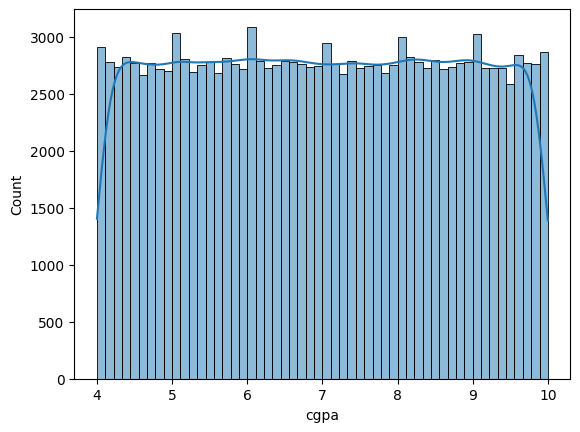

In [42]:
#Section 3: Exploratory Data Analysis (EDA) 
#Plot the distribution of cgpa. Is it normally distributed? Comment on skewness and kurtosis. 
sns.histplot(df['cgpa'],kde=True)
print(df['cgpa'].skew())
#0 → perfectly symmetric
#> 0 (positive skew) → tail on right (more low CGPAs, few high ones)
#< 0 (negative skew) → tail on left (more high CGPAs, few low ones)


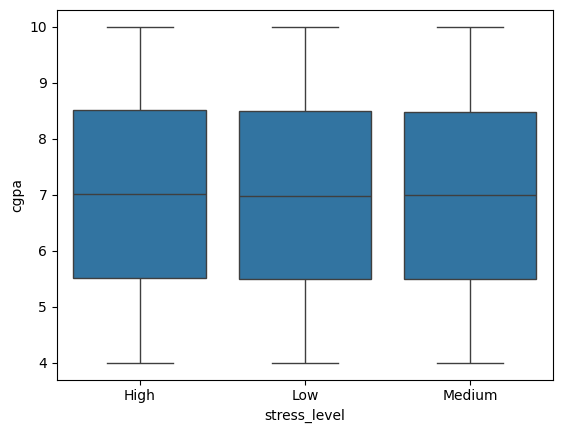

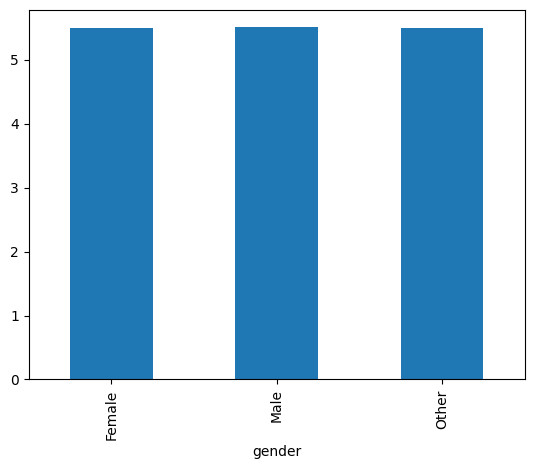

In [43]:
sns.boxplot(x='stress_level', y='cgpa', data=df); plt.show() #Cgpa by stress level
df.groupby('gender')['anxiety_score'].mean().plot(kind='bar'); plt.show() # plot showing average anxiety_score by gender.



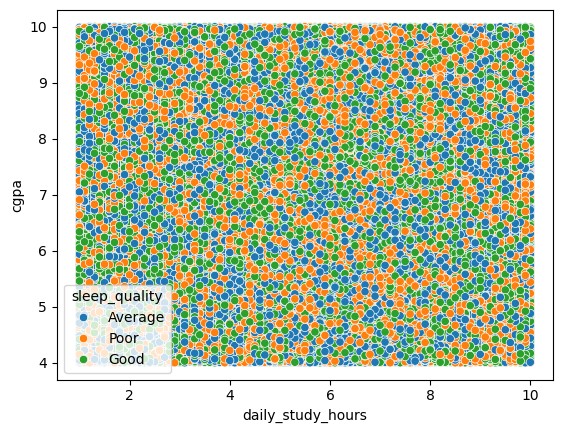

In [44]:
sns.scatterplot(x='daily_study_hours', y='cgpa', hue='sleep_quality', data=df); plt.show() # scatter plot with daily_study_hours on x-axis and cgpa on y-axis, colored by 
#sleep_quality

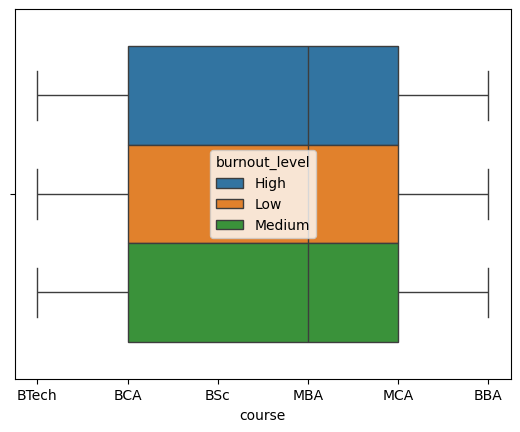

In [45]:
sns.boxplot(x='course', hue='burnout_level', data=df)
plt.show()

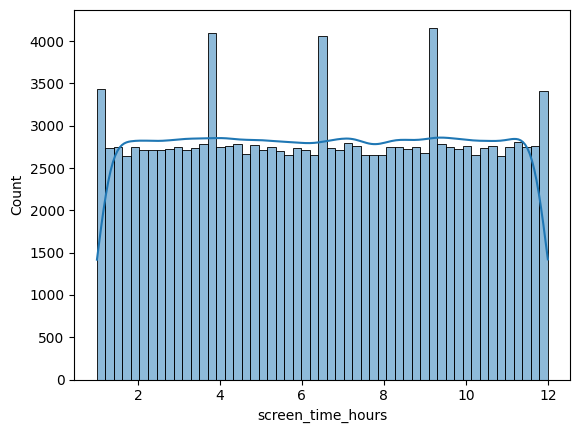

,screen_time_hours,depression_score
20,11.9,6
23,11.7,3
35,11.6,9
102,12.0,9
109,11.9,3
...,...,...
149885,11.8,7
149916,11.8,3
149924,11.7,9
149958,11.6,4


In [46]:
sns.histplot(df['screen_time_hours'], kde=True); plt.show() #Distribution of Screen Time
df[df['screen_time_hours'] > df['screen_time_hours'].quantile(0.95)][['screen_time_hours','depression_score']] #identify extreme values

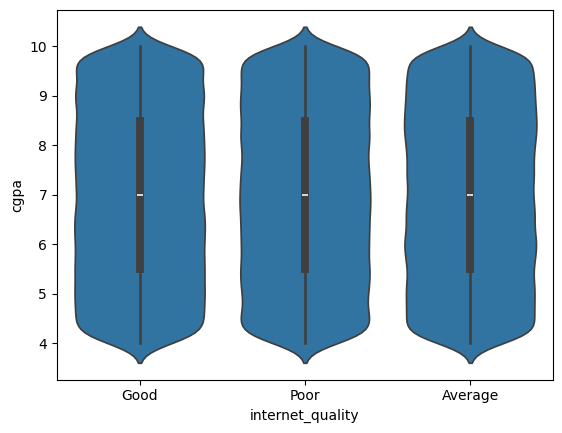

In [47]:
sns.violinplot(x='internet_quality', y='cgpa', data=df); plt.show() #internet and cgpa

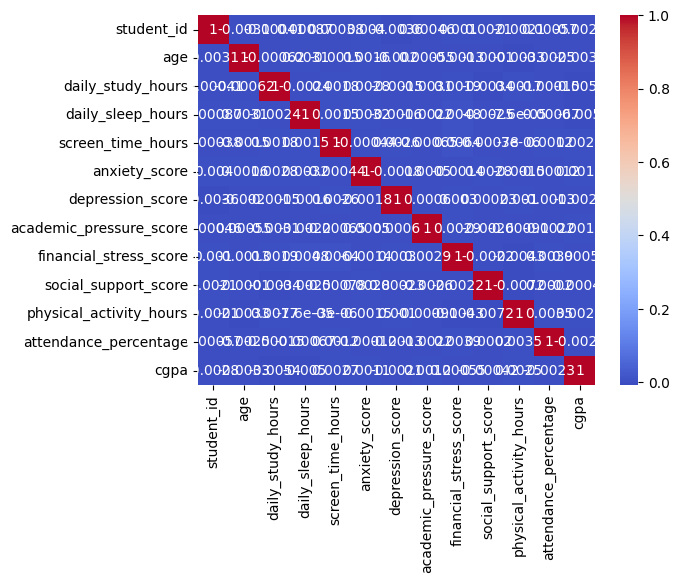

In [48]:
sns.heatmap(df.corr(numeric_only=True), annot=True, cmap='coolwarm'); plt.show() #corealation heatmap

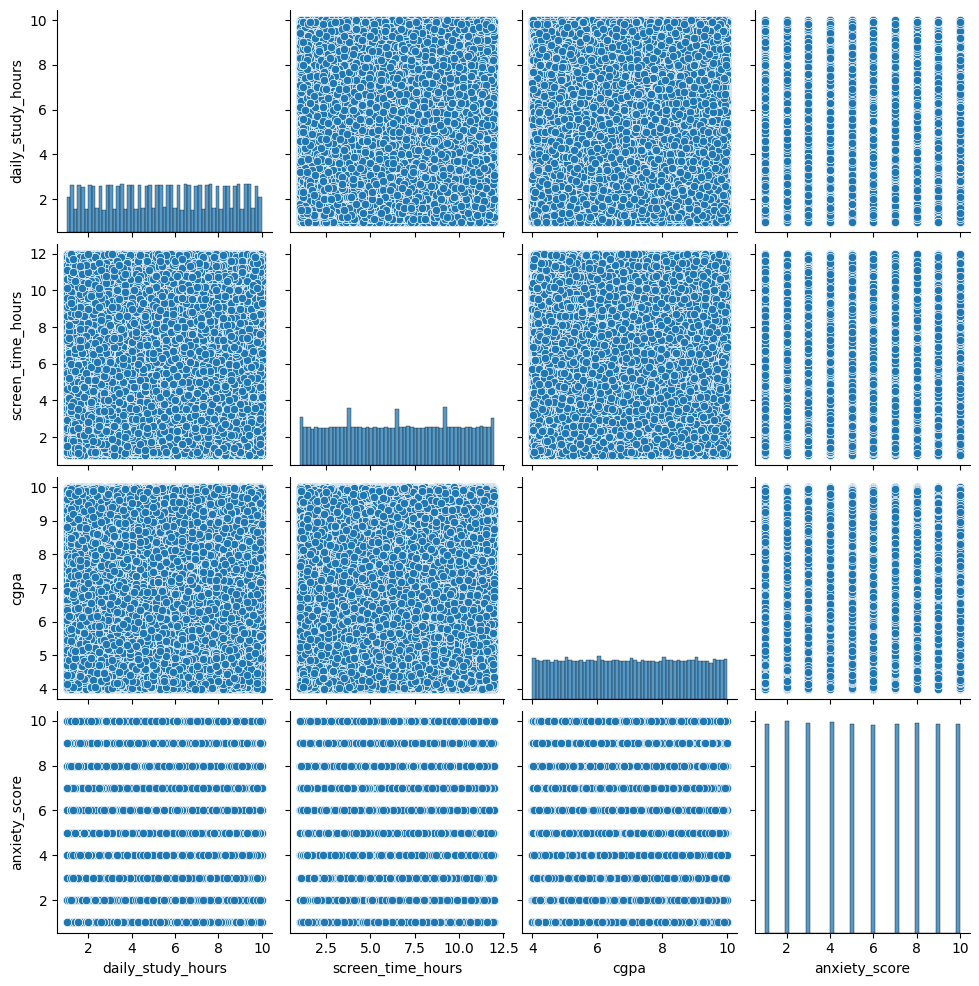

In [49]:
sns.pairplot(df[['daily_study_hours','screen_time_hours','cgpa','anxiety_score']]); plt.show() #pairplot

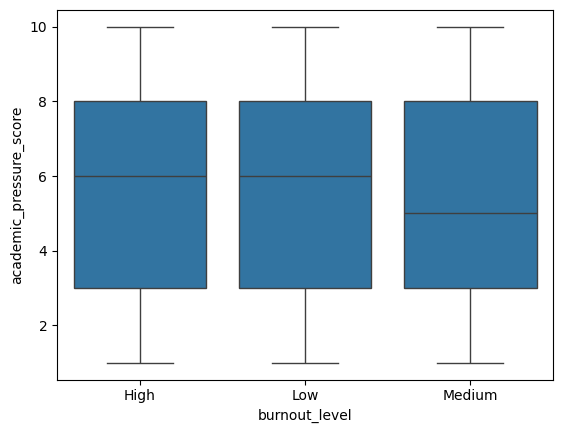

In [50]:
sns.boxplot(x='burnout_level', y='academic_pressure_score', data=df); plt.show() #academic pressure and burnout

Section 4: Model Building — Binary Classification

In [51]:
df['high_burnout'] = df['burnout_level'].apply(lambda x: 1 if x=='High' else 0) #target variable creation

In [55]:
df = pd.get_dummies(df, drop_first=True)
X=df.drop('high_burnout',axis=1)
y=df['high_burnout']

In [ ]:
df.drop(['student_id', 'burnout_level'], axis=1) #leakage cols
#burnout_level → used to create target → leakage
#student_id → useless unique identifier


,age,gender,course,year,daily_study_hours,daily_sleep_hours,screen_time_hours,stress_level,anxiety_score,depression_score,academic_pressure_score,financial_stress_score,social_support_score,physical_activity_hours,sleep_quality,attendance_percentage,cgpa,internet_quality,high_burnout
0,23,Male,BTech,1st,4.3,6.8,6.1,High,10,3,4,2,6,1.8,Average,66.5,9.63,Good,1
1,20,Male,BTech,3rd,1.4,4.7,3.0,High,2,10,8,5,9,1.9,Poor,55.8,6.04,Poor,0
2,24,Female,BCA,4th,3.7,4.8,1.5,Low,2,7,8,6,3,0.8,Good,85.0,8.31,Good,1
3,21,Male,BSc,4th,1.6,6.7,7.0,High,3,3,4,9,9,0.7,Poor,89.1,5.95,Good,1
4,23,Other,BSc,4th,2.0,6.7,5.4,High,7,7,6,4,4,1.7,Good,58.7,8.51,Good,0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
149995,24,Female,BSc,3rd,1.6,8.2,11.3,Medium,9,9,5,3,10,2.0,Good,54.2,7.82,Good,0
149996,25,Male,BCA,3rd,9.9,4.8,1.6,High,10,3,10,10,2,0.1,Poor,53.6,7.19,Average,1
149997,22,Male,BTech,1st,1.4,4.4,4.6,High,10,8,6,4,7,1.6,Good,90.7,9.78,Average,1
149998,19,Male,BSc,3rd,1.5,4.3,1.1,Medium,8,6,5,7,4,1.1,Average,83.9,9.88,Average,0


In [56]:
#train test split
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

In [57]:
model = LogisticRegression(max_iter=1000)
model.fit(X_train, y_train) #model initializing and training
model.score(X_train, y_train) #trainig accuracy

1.0

Section 5: Model Evaluation

In [58]:
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score

y_pred = model.predict(X_test)

accuracy_score(y_test, y_pred)
precision_score(y_test, y_pred)
recall_score(y_test, y_pred)
f1_score(y_test, y_pred)

1.0

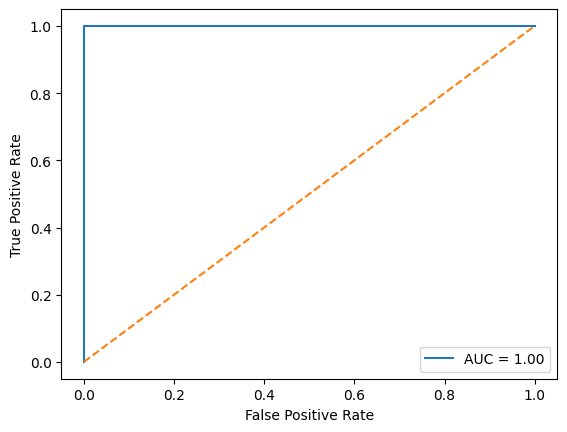

In [60]:


y_prob = model.predict_proba(X_test)[:,1]

fpr, tpr, thresholds = roc_curve(y_test, y_prob)
auc_score = roc_auc_score(y_test, y_prob)

plt.plot(fpr, tpr, label=f"AUC = {auc_score:.2f}")
plt.plot([0,1], [0,1], linestyle='--')  # random line
plt.xlabel("False Positive Rate")
plt.ylabel("True Positive Rate")
plt.legend()
plt.show()

“The ROC curve shows the trade-off between true positive rate and false positive rate. The AUC score indicates the model’s ability to distinguish between classes. An AUC closer to 1 means better performance. If AUC is below 0.7, it may be due to poor feature selection, class imbalance, or underfitting.”

Section 6: Model Interpretation & Critical Thinking

In [61]:
#coefficient extract
coeff = pd.DataFrame({
    "Feature": X.columns,
    "Coefficient": model.coef_[0]
})

coeff = coeff.sort_values(by="Coefficient", ascending=False)
print(coeff)

                    Feature  Coefficient
12                     cgpa     0.131900
1                       age     0.130327
3         daily_sleep_hours     0.125553
26       sleep_quality_Poor     0.074966
17             course_BTech     0.054204
15               course_BCA     0.043185
2         daily_study_hours     0.041056
7   academic_pressure_score     0.040284
4         screen_time_hours     0.038445
27    internet_quality_Good     0.024974
5             anxiety_score     0.023919
8    financial_stress_score     0.021939
9      social_support_score     0.021221
6          depression_score     0.019952
11    attendance_percentage     0.015474
20                 year_2nd     0.008909
0                student_id     0.000004
14             gender_Other    -0.007643
18               course_MBA    -0.011323
21                 year_3rd    -0.020137
19               course_MCA    -0.027035
25       sleep_quality_Good    -0.030389
22                 year_4th    -0.034718
23         stres

In [ ]:
print(df['high_burnout'].value_counts()) #checking im balance classes

In [63]:
from imblearn.over_sampling import SMOTE

sm = SMOTE(random_state=42)
X_res, y_res = sm.fit_resample(X_train, y_train)

model_smote = LogisticRegression(max_iter=1000)
model_smote.fit(X_res, y_res)

y_pred_smote = model_smote.predict(X_test) 

c:\Users\People Links Laptop\AppData\Local\Programs\Python\Python312\Lib\site-packages\sklearn\linear_model\_logistic.py:406: ConvergenceWarning: lbfgs failed to converge after 1000 iteration(s) (status=1):
STOP: TOTAL NO. OF ITERATIONS REACHED LIMIT

Increase the number of iterations to improve the convergence (max_iter=1000).
You might also want to scale the data as shown in:
    https://scikit-learn.org/stable/modules/preprocessing.html
Please also refer to the documentation for alternative solver options:
    https://scikit-learn.org/stable/modules/linear_model.html#logistic-regression
  n_iter_i = _check_optimize_result(


Preprocessing Impact
(a) Without Scaling

Just skip:

# remove StandardScaler
🧠 Why scaling matters?

👉 Logistic Regression = distance-based optimization

Large values dominate model
Small features ignored
✍️ Write:

👉
“Feature scaling ensures all variables contribute equally. Without scaling, features with larger values dominate, leading to unstable coefficients and poor performance.”

(b) Without Outlier Treatment

👉 Outliers = extreme values

Effect:
Coefficients distort ho jate hain
Model unstable
✍️ Write:

👉
“Without outlier treatment, model performance may decrease due to distorted relationships caused by extreme values.”

🔹 4. Model Improvement Strategies
(a) 3 strong strategies
✅ 1. Feature Engineering
New features (ratios, interactions)

👉 improves signal

✅ 2. Hyperparameter tuning
from sklearn.model_selection import GridSearchCV

👉 better model configuration

✅ 3. Try advanced models
Random Forest
XGBoost

👉 capture non-linear pattern

In [ ]:

#L1 Regularization (Feature Selection)
lasso = LogisticRegression(penalty='l1', solver='liblinear')
lasso.fit(X_train, y_train)

coeff_l1 = pd.DataFrame({
    "Feature": X.columns,
    "Coefficient": lasso.coef_[0]
})

print(coeff_l1)

c:\Users\People Links Laptop\AppData\Local\Programs\Python\Python312\Lib\site-packages\sklearn\linear_model\_logistic.py:1135: FutureWarning: 'penalty' was deprecated in version 1.8 and will be removed in 1.10. To avoid this warning, leave 'penalty' set to its default value and use 'l1_ratio' or 'C' instead. Use l1_ratio=0 instead of penalty='l2', l1_ratio=1 instead of penalty='l1', and C=np.inf instead of penalty=None.
  warnings.warn(
c:\Users\People Links Laptop\AppData\Local\Programs\Python\Python312\Lib\site-packages\sklearn\linear_model\_logistic.py:1160: UserWarning: Inconsistent values: penalty=l1 with l1_ratio=0.0. penalty is deprecated. Please use l1_ratio only.
  warnings.warn(


                    Feature  Coefficient
0                student_id     0.000007
1                       age     0.094829
2         daily_study_hours     0.071944
3         daily_sleep_hours     0.220029
4         screen_time_hours     0.045692
5             anxiety_score     0.034692
6          depression_score     0.057478
7   academic_pressure_score     0.066780
8    financial_stress_score     0.061748
9      social_support_score     0.048511
10  physical_activity_hours     0.040375
11    attendance_percentage     0.017400
12                     cgpa     0.119133
13              gender_Male     0.000000
14             gender_Other     0.000000
15               course_BCA     0.000000
16               course_BSc     0.000000
17             course_BTech     0.000000
18               course_MBA     0.000000
19               course_MCA     0.000000
20                 year_2nd     0.000000
21                 year_3rd     0.000000
22                 year_4th     0.000000
23         stres

In [66]:
#6. Cross-Validation
from sklearn.model_selection import cross_val_score

scores = cross_val_score(model, X, y, cv=5)

print("Mean Accuracy:", scores.mean())
print("Std Dev:", scores.std())

c:\Users\People Links Laptop\AppData\Local\Programs\Python\Python312\Lib\site-packages\sklearn\linear_model\_logistic.py:406: ConvergenceWarning: lbfgs failed to converge after 1000 iteration(s) (status=1):
STOP: TOTAL NO. OF ITERATIONS REACHED LIMIT

Increase the number of iterations to improve the convergence (max_iter=1000).
You might also want to scale the data as shown in:
    https://scikit-learn.org/stable/modules/preprocessing.html
Please also refer to the documentation for alternative solver options:
    https://scikit-learn.org/stable/modules/linear_model.html#logistic-regression
  n_iter_i = _check_optimize_result(


Mean Accuracy: 1.0
Std Dev: 0.0
